# Input and Throughput

The quick notebook examplifies how to recover the input spectrum used for the simulation and quick access the effective throughput.

Important methods:
- `get_input_spectrum()`: returns the input spectrum used by the simulation
- `get_effective_transmission()`: returns the total transmission (spectrograph throughput & detector efficiency)
- `get_spectrum()`: returns simulated spectrum as observed (in ADU) with its variance.

In [3]:
import slicersim
import numpy as np


## Load the simulation

In [4]:
config = slicersim.iotools.get_config(scene='supernova.toml')
sim = slicersim.Simulation.from_config(config)

## Get the various elements

In [5]:
lbda, spec = sim.get_input_spectrum()
lbda, throughput = sim.get_effective_transmission()
lbda, eff_spec, eff_var = sim.get_spectrum(incl_error=True)

## And see how it looks

(change `incl_error=True/False`)

/var/folders/kt/dnsb_cyx445cbz2ht_3l2m6w00029p/T/ipykernel_52912/2345797031.py:15: RuntimeWarning: divide by zero encountered in divide
  ax3.plot(lbda, eff_spec/throughput, ls="-", color="C0", label="simulated / throught")


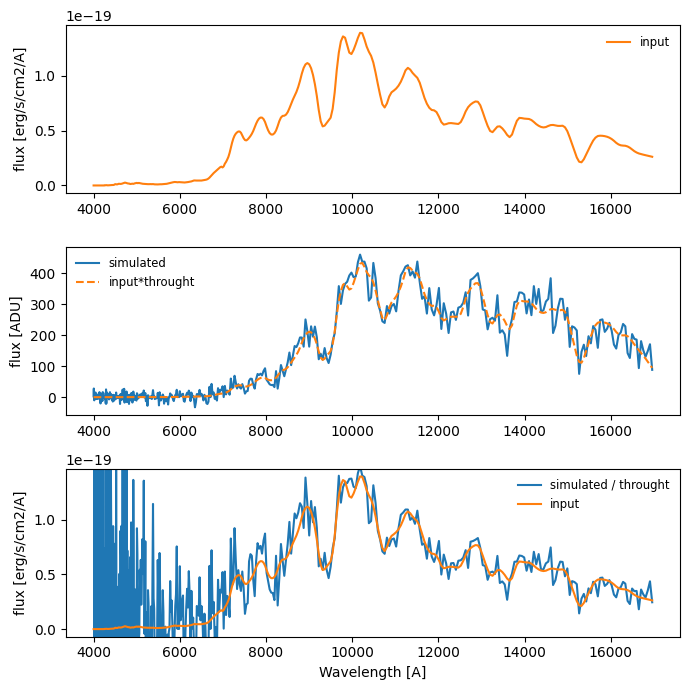

In [6]:
import matplotlib.pyplot as plt

fig, (ax,ax2, ax3) = plt.subplots(3, figsize=[7,7])

ax.plot(lbda, spec, label="input", color="C1")
ax.legend(frameon=False, fontsize="small")
ax.set_ylabel("flux [erg/s/cm2/A]")

ax2.plot(lbda, eff_spec, color="C0", label="simulated")
ax2.plot(lbda, spec*throughput, ls="--", color="C1", label="input*throught")
ax2.legend(frameon=False, fontsize="small")
ax2.set_ylabel("flux [ADU]")


ax3.plot(lbda, eff_spec/throughput, ls="-", color="C0", label="simulated / throught")
ax3.plot(lbda, spec, label="input", color="C1")
ax3.legend(frameon=False, fontsize="small")
ax3.set_ylim(*ax.get_ylim())
ax3.set_ylabel("flux [erg/s/cm2/A]")

ax3.set_xlabel("Wavelength [A]")
fig.tight_layout()